# Analyse Exploratoire

### Import des modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn 

### Analyse Exploratoire

In [ ]:
building_consumption = pd.read_csv('./data/2016_Building_Energy_Benchmarking.csv')

In [3]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.iloc[:, :15].head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980


In [4]:
building_consumption.iloc[:, 15:30].head()

,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf)
0,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997
1,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003
2,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000
3,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003
4,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003


In [5]:
building_consumption.iloc[:, 30:].head()

,SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [6]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [7]:
building_consumption.iloc[:, :15].describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000


In [8]:
building_consumption.iloc[:, 15:30].describe()

,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf)
count,3368.000000,3376.000000,3.376000e+03,3376.000000,3.376000e+03,3.356000e+03,1679.000000,596.000000,2533.000000,3369.000000
mean,1.106888,4.709123,9.483354e+04,8001.526066,8.683201e+04,7.917764e+04,28444.075817,11738.675166,67.918674,54.732116
std,2.108402,5.494465,2.188376e+05,32326.723928,2.079398e+05,2.017034e+05,54392.917928,29331.199286,26.873271,56.273124
min,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.000000
25%,1.000000,2.000000,2.848700e+04,0.000000,2.775600e+04,2.509475e+04,5000.000000,2239.000000,53.000000,27.900000
50%,1.000000,4.000000,4.417500e+04,0.000000,4.321600e+04,3.989400e+04,10664.000000,5043.000000,75.000000,38.599998
75%,1.000000,5.000000,9.099200e+04,0.000000,8.427625e+04,7.620025e+04,26640.000000,10138.750000,90.000000,60.400002
max,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,100.000000,834.400024


In [9]:
building_consumption.iloc[:, 30:-1].describe()

,SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions
count,3370.000000,3367.000000,3367.000000,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000
mean,57.033798,134.232848,137.783932,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971
std,57.163330,139.287554,139.109807,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227
min,0.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000
25%,29.400000,74.699997,78.400002,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000
50%,40.900002,96.199997,101.099998,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000
75%,64.275002,143.899994,148.349998,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000
max,834.400024,2620.000000,2620.000000,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000


## Analyse descriptive des variables numériques

Le dataset contient **3376 bâtiments** avec des caractéristiques structurelles, géographiques et énergétiques.

### 1. Informations générales et géographiques

- Toutes les observations proviennent de l'année **2016** ('DataYear').
- Les codes postaux ('ZipCode') sont compris entre **98006 et 98272**, ce qui correspond à la région de Seattle.  
- Les coordonnées géographiques montrent que les bâtiments sont situés dans une zone relativement restreinte :  
  - Latitude moyenne : **47.62**  
  - Longitude moyenne : **-122.33**

- Les bâtiments ont été construits entre **1900 et 2015**, avec :  
  - moyenne : **1968**  
  - médiane : **1975**

Cela indique que **la majorité des bâtiments sont relativement anciens**, ce qui peut influencer leur efficacité énergétique.

### 2. Caractéristiques physiques des bâtiments

- Le nombre moyen de bâtiments par propriété ('NumberofBuildings') est **1.1**, mais la valeur maximale est **111**, ce qui semble **anormalement élevé** et pourrait correspondre à un complexe immobilier.  

- Le nombre d'étages ('NumberofFloors') varie entre **0 et 99**.  
  - Une valeur de **0 étage est illogique** pour un bâtiment et peut correspondre à une erreur ou à un cas particulier.

- La surface totale ('PropertyGFATotal') montre une très forte dispersion :  
  - moyenne : **94 833 ft²**  
  - médiane : **44 175 ft²**  
  - maximum : **9 320 156 ft²**

La grande différence entre la moyenne et la médiane indique la présence de **bâtiments extrêmement grands (outliers)**.  
> La forte dispersion de la surface suggère que **la taille du bâtiment sera probablement une variable explicative importante de la consommation énergétique**.


### 3. Utilisation des surfaces

La surface principale utilisée ('LargestPropertyUseTypeGFA') est en moyenne **79 177 ft²**, mais peut atteindre **9 320 156 ft²**.  

Les surfaces secondaires présentent beaucoup de valeurs manquantes :  

- 'SecondLargestPropertyUseTypeGFA' : seulement **1679 valeurs**  
- 'ThirdLargestPropertyUseTypeGFA' : seulement **596 valeurs**

Cela signifie que **beaucoup de bâtiments n'ont qu'un seul type d'utilisation principale**.


### 4. Performance énergétique

L'indicateur **'ENERGYSTARScore'** varie entre **1 et 100**, avec une moyenne de **67.9**, ce qui suggère une **grande hétérogénéité dans la performance énergétique des bâtiments**.

Les indicateurs d'intensité énergétique montrent une forte dispersion :  

- 'SiteEUI(kBtu/sf)' : moyenne **54.7**, maximum **834.4**  
- 'SourceEUI(kBtu/sf)' : moyenne **134.2**, maximum **2620**

Ces valeurs maximales sont **très élevées**, ce qui suggère la présence de **bâtiments très énergivores ou de valeurs aberrantes**.


### 5. Consommation énergétique

La consommation totale ('SiteEnergyUse(kBtu)') présente une distribution très asymétrique :  

- moyenne : **5.4 millions kBtu**  
- médiane : **1.8 million kBtu**  
- maximum : **873 millions kBtu**

Cela montre que **quelques bâtiments consomment énormément d'énergie**.

L'électricité consommée ('Electricity(kWh)') :  

- moyenne : **1 086 639 kWh**  
- maximum : **192 577 500 kWh**

Le gaz naturel ('NaturalGas(kBtu)') peut atteindre **297 909 000 kBtu**, ce qui confirme l'existence de **très gros consommateurs d'énergie**.

> Ces observations suggèrent que **la consommation énergétique sera fortement corrélée à la taille du bâtiment et à son usage principal**.


### 6. Émissions de gaz à effet de serre

Les émissions totales ('TotalGHGEmissions') montrent une forte dispersion :  

- moyenne : **119.7 tonnes**  
- médiane : **33.9 tonnes**  
- maximum : **16 870.98 tonnes**

> Cela indique que certains bâtiments sont **responsables d'émissions très importantes**.

### 7. Valeurs illogiques détectées

Plusieurs valeurs observées dans les données semblent **impossibles ou incohérentes** :  

- 'NumberofFloors' minimum : **0** (un bâtiment ne peut normalement pas avoir 0 étage)  
- 'Electricity(kWh)' minimum : **-33 826**  
- 'Electricity(kBtu)' minimum : **-115 417**  
- 'SourceEUIWN(kBtu/sf)' minimum : **-2.1**  
- 'TotalGHGEmissions' minimum : **-0.8**

> Ces observations devront être soit supprimées soit corrigées lors de la phase de nettoyage afin d'éviter d'introduire du bruit dans les modèles de prédiction.

### 8. Variables problématiques

- 'Comments' contient **0 valeurs non nulles**, donc cette variable est **entièrement vide** et peut être supprimée.  
- 'DataYear' contient **toujours la même valeur (2016)**, elle n'apporte donc **aucune information utile pour la modélisation**.

### 9. Conclusion

L'analyse descriptive met en évidence :  

- une **forte variabilité dans la taille et la consommation énergétique des bâtiments**  
- la présence de **valeurs extrêmes (outliers)** dans plusieurs variables  
- des **valeurs incohérentes ou physiquement impossibles** (valeurs négatives ou nulles)

> Ces observations indiquent qu'une **phase de nettoyage et de préparation des données sera nécessaire** avant d'entraîner les modèles de prédiction.  
> Par ailleurs, certaines variables comme la **surface totale du bâtiment** ou les **indicateurs d'intensité énergétique** semblent potentiellement fortement liées à la consommation énergétique et pourront jouer un rôle important dans la modélisation.

In [10]:
building_consumption.shape

(3376, 46)

In [11]:
cols_unit = building_consumption.loc[:, building_consumption.count() <= int(len(building_consumption)/2)]
cols_unit

,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,Comments,Outlier
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Parking,15064.0,Restaurant,4622.0,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Parking,68009.0,Swimming Pool,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...
3371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3373,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,NaN,NaN,NaN
3374,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,NaN,NaN,NaN


In [12]:
data= building_consumption.drop(columns=cols_unit.columns).copy()

In [13]:
data.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,Compliant,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,Compliant,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,Compliant,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,Compliant,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,Compliant,505.01,2.88


In [14]:
cols = data.loc[:, data.count() <len(data)]
cols.isna().sum()

ZipCode                       16
NumberofBuildings              8
ListOfAllPropertyUseTypes      9
LargestPropertyUseType        20
LargestPropertyUseTypeGFA     20
ENERGYSTARScore              843
SiteEUI(kBtu/sf)               7
SiteEUIWN(kBtu/sf)             6
SourceEUI(kBtu/sf)             9
SourceEUIWN(kBtu/sf)           9
SiteEnergyUse(kBtu)            5
SiteEnergyUseWN(kBtu)          6
SteamUse(kBtu)                 9
Electricity(kWh)               9
Electricity(kBtu)              9
NaturalGas(therms)             9
NaturalGas(kBtu)               9
TotalGHGEmissions              9
GHGEmissionsIntensity          9
dtype: int64

In [15]:
zipmq=data[data['ZipCode'].isna()]
zipmq

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
3360,50196,2016,Nonresidential COS,Mixed Use Property,Northgate Community Center,10510 5th Ave NE,Seattle,WA,NaN,2926049431,...,6.369655e+05,0.0,186683.90630,6.369655e+05,0.000000,0.000000e+00,False,Compliant,4.44,0.22
3361,50198,2016,Nonresidential COS,Other,Fire Station 06 (New),405 MLK Jr Way S,Seattle,WA,NaN,1250200565,...,9.691420e+05,0.0,101784.50000,3.472887e+05,5037.649902,5.037650e+05,False,Compliant,29.18,2.50
3362,50201,2016,Nonresidential COS,Other,Fire Station 35 (New),8729 15th Ave NW,Seattle,WA,NaN,3300700810,...,8.587730e+05,0.0,118183.79690,4.032431e+05,3801.799805,3.801800e+05,False,Compliant,23.00,1.92
3363,50204,2016,Nonresidential COS,Other,Fire Station 39 (New),2806 NE 127th St,Seattle,WA,NaN,3834500066,...,7.059837e+05,0.0,126552.00000,4.317954e+05,2138.700195,2.138700e+05,False,Compliant,14.37,1.27
3364,50207,2016,Nonresidential COS,Other,Ballard Community Center,6020 28th ave NW,Seattle,WA,NaN,6658000065,...,9.905455e+05,0.0,158890.50000,5.421344e+05,3944.819824,3.944820e+05,False,Compliant,24.73,1.47
3365,50208,2016,Nonresidential COS,Other,Ballard Pool,1471 NW 67th St,Seattle,WA,NaN,3050700005,...,5.370264e+06,0.0,353216.09380,1.205173e+06,39121.351560,3.912135e+06,False,Compliant,216.18,16.93
3366,50210,2016,Nonresidential COS,Office,Central West HQ / Brown Bear,1403 w howe,Seattle,WA,NaN,2425039137,...,5.585251e+05,0.0,147323.50000,5.026678e+05,0.000000,0.000000e+00,True,Error - Correct Default Data,3.50,0.26
3367,50212,2016,Nonresidential COS,Other,Conservatory Campus,1400 E Galer St,Seattle,WA,NaN,2925049087,...,6.716330e+06,0.0,369539.81250,1.260870e+06,47153.757810,4.715376e+06,False,Compliant,259.22,11.06
3368,50219,2016,Nonresidential COS,Mixed Use Property,Garfield Community Center,2323 East Cherry St,Seattle,WA,NaN,7544800245,...,1.993137e+06,0.0,225513.79690,7.694531e+05,10439.510740,1.043951e+06,False,Compliant,60.81,3.03
3369,50220,2016,Nonresidential COS,Office,Genesee/SC SE HQ,4420 S Genesee,Seattle,WA,NaN,4154300585,...,4.141724e+05,0.0,81341.39844,2.775369e+05,1102.729980,1.102730e+05,True,Error - Correct Default Data,7.79,0.51


In [16]:
for idx, row in zipmq.iterrows():
    # Chercher une ligne dans le dataset avec mêmes Latitude et Longitude et ZipCode non manquant
    match = data[(data['Latitude'] == row['Latitude']) &
                 (data['Longitude'] == row['Longitude']) &
                 (data['ZipCode'].notna())]
    
    if not match.empty:
        # Copier le ZipCode trouvé
        data.at[idx, 'ZipCode'] = match.iloc[0]['ZipCode']
zipmq.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
3360,50196,2016,Nonresidential COS,Mixed Use Property,Northgate Community Center,10510 5th Ave NE,Seattle,WA,NaN,2926049431,...,636965.5000,0.0,186683.9063,636965.4881,0.000000,0.0000,False,Compliant,4.44,0.22
3361,50198,2016,Nonresidential COS,Other,Fire Station 06 (New),405 MLK Jr Way S,Seattle,WA,NaN,1250200565,...,969142.0000,0.0,101784.5000,347288.7140,5037.649902,503764.9902,False,Compliant,29.18,2.50
3362,50201,2016,Nonresidential COS,Other,Fire Station 35 (New),8729 15th Ave NW,Seattle,WA,NaN,3300700810,...,858773.0000,0.0,118183.7969,403243.1149,3801.799805,380179.9805,False,Compliant,23.00,1.92
3363,50204,2016,Nonresidential COS,Other,Fire Station 39 (New),2806 NE 127th St,Seattle,WA,NaN,3834500066,...,705983.6875,0.0,126552.0000,431795.4240,2138.700195,213870.0195,False,Compliant,14.37,1.27
3364,50207,2016,Nonresidential COS,Other,Ballard Community Center,6020 28th ave NW,Seattle,WA,NaN,6658000065,...,990545.5000,0.0,158890.5000,542134.3860,3944.819824,394481.9824,False,Compliant,24.73,1.47


In [17]:
data['ZipCode'].isna().sum()

np.int64(14)

In [18]:
data = data[data['ZipCode'].notna()]
data.shape

(3362, 39)

## Nettoyage des ZipCode manquants

- Certaines lignes du dataset avaient un **ZipCode manquant**.
- Pour ces bâtiments, nous avons recherché dans le dataset **un autre bâtiment aux mêmes coordonnées (`Latitude` et `Longitude`)** avec un ZipCode défini, et nous avons copié ce ZipCode.
- Les lignes restantes **sans correspondance** ont été **supprimées** afin de garantir que toutes les observations aient un ZipCode valide pour l’analyse et la modélisation.
- Après ce nettoyage, le dataset ne contient plus de valeurs manquantes dans la colonne `ZipCode`.

In [19]:
cols = data.loc[:, data.count() <len(data)]
cols.isna().sum()

NumberofBuildings              8
ListOfAllPropertyUseTypes      9
LargestPropertyUseType        20
LargestPropertyUseTypeGFA     20
ENERGYSTARScore              832
SiteEUI(kBtu/sf)               7
SiteEUIWN(kBtu/sf)             6
SourceEUI(kBtu/sf)             9
SourceEUIWN(kBtu/sf)           9
SiteEnergyUse(kBtu)            5
SiteEnergyUseWN(kBtu)          6
SteamUse(kBtu)                 9
Electricity(kWh)               9
Electricity(kBtu)              9
NaturalGas(therms)             9
NaturalGas(kBtu)               9
TotalGHGEmissions              9
GHGEmissionsIntensity          9
dtype: int64

In [20]:
data['ENERGYSTARScore'].fillna(data['ENERGYSTARScore'].median(), inplace=True)
data['ENERGYSTARScore'].isna().sum()
#data['ENERGYSTARScore'].describe()

np.int64(0)

## Nettoyage de la colonne ENERGYSTARScore

- La colonne `ENERGYSTARScore` comporte **832 valeurs manquantes**.
Comme il n’existe pas de méthode plus précise pour estimer ces valeurs, nous avons choisi de remplacer **les valeurs manquantes par la médiane** de la colonne. Cette approche permet de limiter l’impact des valeurs extrêmes et de mieux représenter la distribution réelle des performances énergétiques.
- Cette approche permet de conserver toutes les observations et de maintenir la distribution globale des scores.
- Après cette opération, toutes les lignes ont désormais un `ENERGYSTARScore` valide pour la modélisation.

In [21]:
data[data['NumberofBuildings'].isna()]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
578,773,2016,NonResidential,Small- and Mid-Sized Office,SEATTLE BUILDING,215 COLUMBIA ST,Seattle,WA,98104.0,0939000245,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Non-Compliant,NaN,NaN
758,19798,2016,Multifamily LR (1-4),Low-Rise Multifamily,SANDHURST APTS,7239 SAND POINT WAY NE,Seattle,WA,98115.0,0225049032,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Non-Compliant,NaN,NaN
1768,23355,2016,Multifamily LR (1-4),Low-Rise Multifamily,GRAHAM VIEW,6040 CALIFORNIA AVE SW,Seattle,WA,98136.0,7625703280,...,593798.625,NaN,NaN,NaN,NaN,NaN,False,Compliant,NaN,NaN
1792,23437,2016,Multifamily LR (1-4),Low-Rise Multifamily,MERCER CREST APT,500 W MERCER ST,Seattle,WA,98119.0,3876900230,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Non-Compliant,NaN,NaN
2321,25431,2016,Multifamily LR (1-4),Low-Rise Multifamily,PONDERAY APTS,5625 15TH AVE NE,Seattle,WA,98105.0,5226300030,...,797507.000,NaN,NaN,NaN,NaN,NaN,False,Compliant,NaN,NaN
2474,25752,2016,Multifamily LR (1-4),Low-Rise Multifamily,GRANVIEW APARTMENTS,1120 N 93RD ST,Seattle,WA,98103.0,9267200155,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Non-Compliant,NaN,NaN
2480,25763,2016,Multifamily LR (1-4),Low-Rise Multifamily,Villa Andora,1520 CALIFORNIA AVE SW,Seattle,WA,98116.0,9272201340,...,1126781.750,NaN,NaN,NaN,NaN,NaN,False,Compliant,NaN,NaN
2670,26532,2016,NonResidential,Mixed Use Property,KALBERG BUILDING,4515 UNIVERSITY WAY NE,Seattle,WA,98105.0,8816401120,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Non-Compliant,NaN,NaN


In [22]:
data = data[data['NumberofBuildings'].notna()]
data.shape

(3354, 39)

In [23]:
cols = data.loc[:, data.count() <len(data)]
cols.isna().sum()

ListOfAllPropertyUseTypes     1
LargestPropertyUseType       12
LargestPropertyUseTypeGFA    12
SiteEUI(kBtu/sf)              2
SiteEUIWN(kBtu/sf)            1
SourceEUI(kBtu/sf)            1
SourceEUIWN(kBtu/sf)          1
SiteEnergyUseWN(kBtu)         1
SteamUse(kBtu)                1
Electricity(kWh)              1
Electricity(kBtu)             1
NaturalGas(therms)            1
NaturalGas(kBtu)              1
TotalGHGEmissions             1
GHGEmissionsIntensity         1
dtype: int64

In [24]:
data = data[data['TotalGHGEmissions'].notna()]
data.shape

(3353, 39)

In [25]:
data[['LargestPropertyUseType', 'LargestPropertyUseTypeGFA','ListOfAllPropertyUseTypes']]

,LargestPropertyUseType,LargestPropertyUseTypeGFA,ListOfAllPropertyUseTypes
0,Hotel,88434.0,Hotel
1,Hotel,83880.0,"Hotel, Parking, Restaurant"
2,Hotel,756493.0,Hotel
3,Hotel,61320.0,Hotel
4,Hotel,123445.0,"Hotel, Parking, Swimming Pool"
...,...,...,...
3357,Multifamily Housing,168221.0,"Multifamily Housing, Parking"
3358,Multifamily Housing,17666.0,Multifamily Housing
3359,College/University,68916.0,College/University
3360,Other - Recreation,9900.0,"Fitness Center/Health Club/Gym, Office, Other ..."


In [26]:
data.loc[data['LargestPropertyUseType'].isna(), 
         ['LargestPropertyUseType', 'LargestPropertyUseTypeGFA','ListOfAllPropertyUseTypes']]

,LargestPropertyUseType,LargestPropertyUseTypeGFA,ListOfAllPropertyUseTypes
353,NaN,NaN,"Fitness Center/Health Club/Gym, Office, Other ..."
1077,NaN,NaN,Multifamily Housing
1147,NaN,NaN,Hotel
1483,NaN,NaN,Multifamily Housing
1756,NaN,NaN,Multifamily Housing
2336,NaN,NaN,Multifamily Housing
2414,NaN,NaN,Office
2459,NaN,NaN,Restaurant
2545,NaN,NaN,Multifamily Housing
2886,NaN,NaN,Multifamily Housing


In [27]:
# Remplir LargestPropertyUseType si ListOfAllPropertyUseTypes contient une seule valeur
def fill_largest_use(row):
    if pd.isna(row['LargestPropertyUseType']):
        # Séparer par virgule et enlever les espaces
        uses = [u.strip() for u in str(row['ListOfAllPropertyUseTypes']).split(',')]
        if len(uses) == 1:
            return uses[0]
    return row['LargestPropertyUseType']

data['LargestPropertyUseType'] = data.apply(fill_largest_use, axis=1)

#  Remplir LargestPropertyUseTypeGFA par la moyenne des GFA pour le type correspondant
mean_gfa = data.groupby('LargestPropertyUseType')['LargestPropertyUseTypeGFA'].median()

def fill_largest_gfa(row):
    if pd.isna(row['LargestPropertyUseTypeGFA']):
        use_type = row['LargestPropertyUseType']
        if pd.notna(use_type) and use_type in mean_gfa.index:
            return mean_gfa[use_type]
    return row['LargestPropertyUseTypeGFA']

data['LargestPropertyUseTypeGFA'] = data.apply(fill_largest_gfa, axis=1)

In [28]:
cols = data.loc[:, data.count() <len(data)]
cols.isna().sum()

LargestPropertyUseType       2
LargestPropertyUseTypeGFA    2
SiteEUI(kBtu/sf)             2
SiteEUIWN(kBtu/sf)           1
SiteEnergyUseWN(kBtu)        1
dtype: int64

In [29]:
# data = data[~data["BuildingType"].str.contains("Multifamily", na=False)]
# Puisque l’analyse porte sur les bâtiments non résidentiels,
# j’ai tenté de supprimer les catégories contenant "Multifamily".
# Cependant, cette opération réduit considérablement la taille du dataset
# (de 3376 à 1668 observations), ce qui peut être problématique
# pour la suite du projet.

### Traitement des valeurs manquantes pour l’usage principal

Certaines lignes avaient des valeurs manquantes pour :  
- `LargestPropertyUseType`  
- `LargestPropertyUseTypeGFA`  

**Stratégie appliquée :**  
1. Si `ListOfAllPropertyUseTypes` contient une seule valeur, on la copie dans `LargestPropertyUseType`.  
2. Pour `LargestPropertyUseTypeGFA`, si la valeur est manquante, on remplace par la moyenne des GFA pour le même type de bâtiment.  


#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

# Modélisation 

### Import des modules 

In [30]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

# CODE FEATURE ENGINEERING

Après avoir nettoyé les données lors de l’étape 1, nous approfondissons maintenant l’analyse.
Étant donné que les variables cibles sont la consommation d’énergie et les émissions de CO2, nous commençons dans un premier temps par nous concentrer sur la consommation d’énergie comme variable cible. Nous étudierons ensuite les émissions de CO2 dans un second temps si nécessaire.

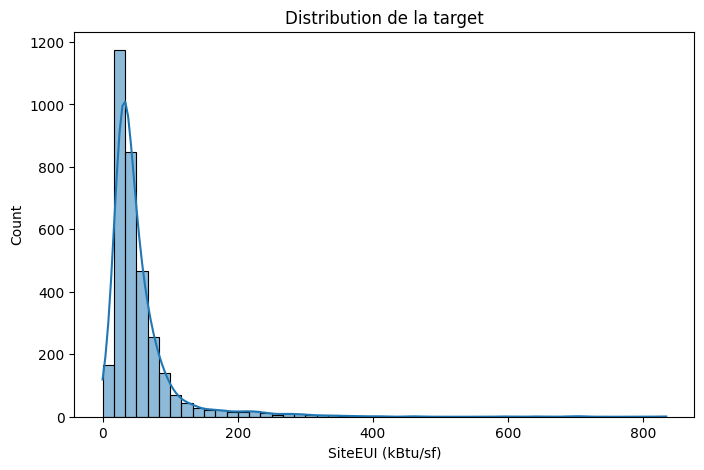

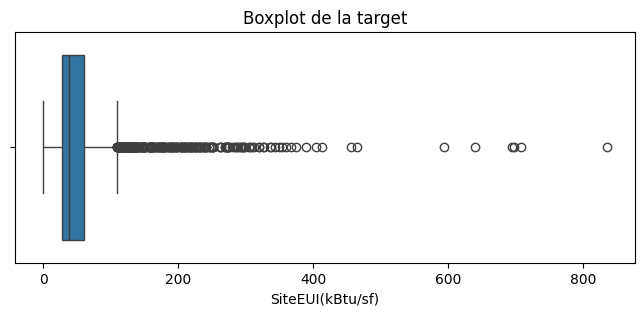

In [31]:
# Choix de la target
y = data['SiteEUI(kBtu/sf)']  # TotalGHGEmissions aussi mais pas maintenant 

# Histogramme
plt.figure(figsize=(8,5))
sbn.histplot(y, bins=50, kde=True)
plt.title('Distribution de la target')
plt.xlabel('SiteEUI (kBtu/sf)')
plt.savefig('histogramme.png')  
plt.show()

# Boxplot pour repérer les outliers
plt.figure(figsize=(8,3))
sbn.boxplot(x=y)
plt.title('Boxplot de la target')
plt.savefig('boxplot.png')  
plt.show()

L’histogramme met en évidence une forte asymétrie des données. Le boxplot confirme également la présence d’un grand nombre d’outliers, avec des valeurs extrêmes très éloignées.
Il ne s’agit pas de quelques points isolés, mais de nombreuses valeurs élevées. Ces observations peuvent correspondre soit à des erreurs de mesure, soit à des bâtiments réellement très énergivores.

#### Matrice de corrélation :
Dans cette étape, nous affichons la matrice de corrélation afin d’analyser les relations entre les différentes variables du jeu de données.

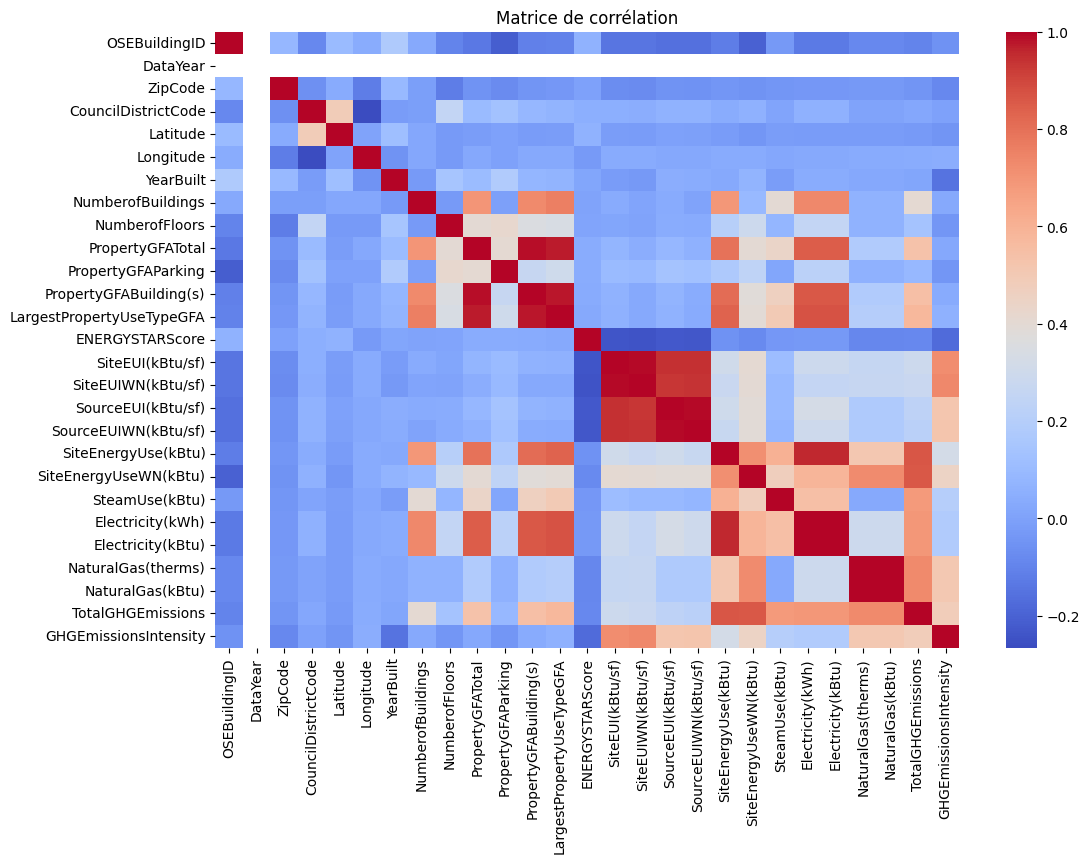

In [32]:
data_num = data.select_dtypes(include=['int64', 'float64'])
corr = data_num.corr()
# affichage heatmap
plt.figure(figsize=(12,8))
sbn.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Matrice de corrélation")
plt.savefig('matrice_corre')
plt.show()

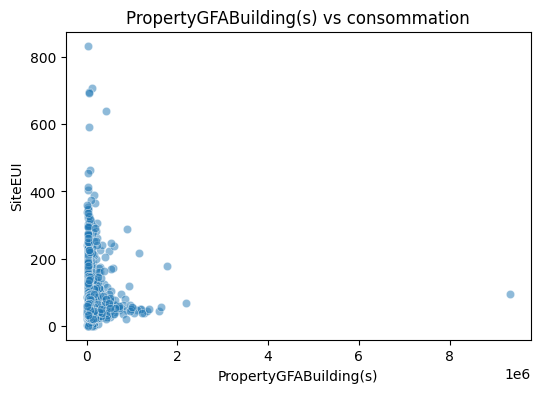

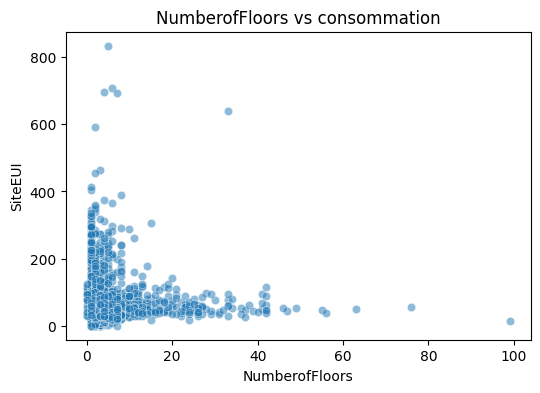

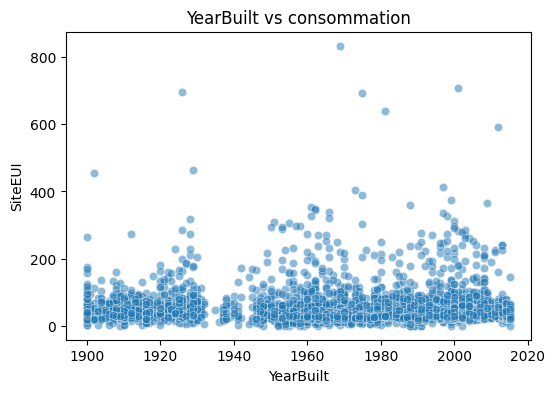

In [33]:
# liste de variables numériques intéressantes
num_cols = [
    'PropertyGFABuilding(s)',
    'NumberofFloors',
    'YearBuilt'
]

# boucle pour tracer plusieurs graphiques
for col in num_cols:
    plt.figure(figsize=(6,4))
    sbn.scatterplot(x=data[col], y=y, alpha=0.5)
    plt.title(f"{col} vs consommation")
    plt.xlabel(col)
    plt.ylabel("SiteEUI")
    plt.savefig(f"{col}.png")
    plt.show()

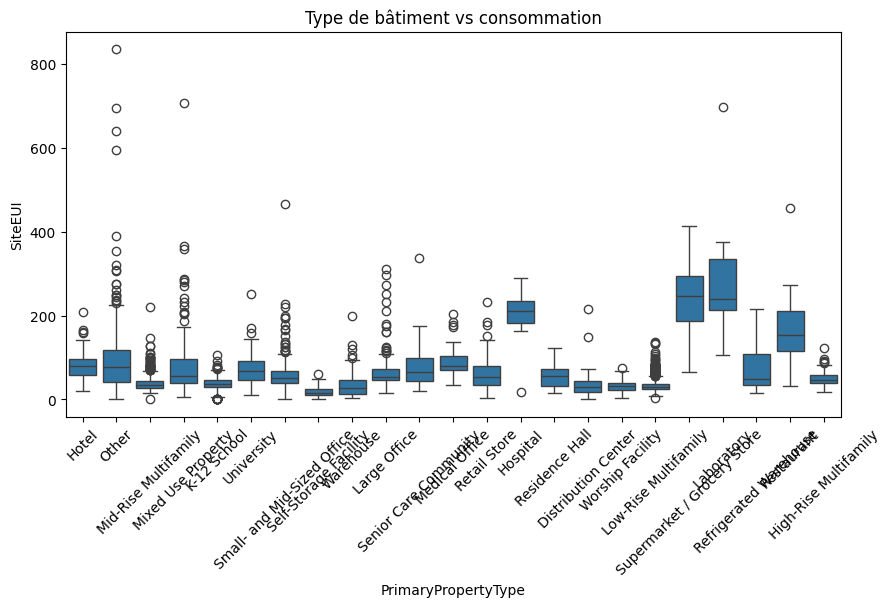

In [34]:
plt.figure(figsize=(10,5))
sbn.boxplot(x=data['PrimaryPropertyType'], y=y)
plt.xticks(rotation=45)
plt.title("Type de bâtiment vs consommation")
plt.ylabel("SiteEUI")
plt.savefig("PrimaryPropertyType.png")
plt.show()

In [35]:
# Copie du dataset
df = data.copy()

# =========================
# Feature engineering
# =========================

# Âge du bâtiment
df['BuildingAge'] = 2016 - df['YearBuilt']

# Surface par étage (éviter division par 0)
df['AreaPerFloor'] = df['PropertyGFABuilding(s)'] / df['NumberofFloors'].replace(0, 1) #pour éviter la division sur 0

# Nombre d'usages : ici on utilise seulement la liste complète
df['NbUses'] = df['ListOfAllPropertyUseTypes'].fillna('').apply(lambda x: len(x.split(',')) if x != '' else 0)

# Présence d'électricité et de gaz
df['HasElectricity'] = (df['Electricity(kWh)'] > 0).astype(int)
df['HasGas'] = (df['NaturalGas(therms)'] > 0).astype(int)

# =========================
# Suppression colonnes inutiles / leakage / redondantes
# =========================

col_sup = [
    # identifiants / texte inutile
    'OSEBuildingID', 'PropertyName', 'Address', 'City', 'State',
    'TaxParcelIdentificationNumber',

    # colonnes peu utiles
    'DataYear', 'DefaultData', 'ComplianceStatus',

    # colonnes redondantes ou à transformer
    'YearBuilt', 'PropertyGFATotal', 'PropertyGFAParking',
    'ListOfAllPropertyUseTypes',

    # variables énergétiques = data leakage 
    'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)',
    'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)',
    'NaturalGas(therms)', 'NaturalGas(kBtu)',

    # autres cibles à prédire
    'TotalGHGEmissions', 'GHGEmissionsIntensity'
]

df = df.drop(columns=col_sup, errors='ignore')

# =========================
# Définition X et y
# =========================

y = df['SiteEUI(kBtu/sf)']
X = df.drop(columns=['SiteEUI(kBtu/sf)'])

# Vérification
print("Shape de X :", X.shape)
print("Shape de y :", y.shape)
print(X.columns)

Shape de X : (3353, 18)
Shape de y : (3353,)
Index(['BuildingType', 'PrimaryPropertyType', 'ZipCode', 'CouncilDistrictCode',
       'Neighborhood', 'Latitude', 'Longitude', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFABuilding(s)', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'BuildingAge',
       'AreaPerFloor', 'NbUses', 'HasElectricity', 'HasGas'],
      dtype='object')


In [36]:
X.head(8)

,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,ENERGYSTARScore,BuildingAge,AreaPerFloor,NbUses,HasElectricity,HasGas
0,NonResidential,Hotel,98101.0,7,DOWNTOWN,47.61220,-122.33799,1.0,12,88434,Hotel,88434.0,60.0,89,7369.500000,1,1,1
1,NonResidential,Hotel,98101.0,7,DOWNTOWN,47.61317,-122.33393,1.0,11,88502,Hotel,83880.0,61.0,20,8045.636364,3,1,1
2,NonResidential,Hotel,98101.0,7,DOWNTOWN,47.61393,-122.33810,1.0,41,759392,Hotel,756493.0,43.0,47,18521.756098,1,1,1
3,NonResidential,Hotel,98101.0,7,DOWNTOWN,47.61412,-122.33664,1.0,10,61320,Hotel,61320.0,56.0,90,6132.000000,1,1,1
4,NonResidential,Hotel,98121.0,7,DOWNTOWN,47.61375,-122.34047,1.0,18,113580,Hotel,123445.0,75.0,36,6310.000000,3,1,1
5,Nonresidential COS,Other,98101.0,7,DOWNTOWN,47.61623,-122.33657,1.0,2,60090,Police Station,88830.0,75.0,17,30045.000000,1,1,1
6,NonResidential,Hotel,98101.0,7,DOWNTOWN,47.61390,-122.33283,1.0,11,83008,Hotel,81352.0,27.0,90,7546.181818,1,1,1
7,NonResidential,Other,98101.0,7,DOWNTOWN,47.61327,-122.33136,1.0,8,102761,Other - Entertainment/Public Assembly,102761.0,75.0,90,12845.125000,1,1,1


In [37]:
# One-Hot Encoding pour BuildingType
buil = pd.get_dummies(X['BuildingType'], prefix='BuildingType', drop_first=True)

# Ajouter au dataset
X = pd.concat([X, buil], axis=1)

# Supprimer la colonne originale
X = X.drop(columns=['BuildingType'])

X.head(8)

,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),LargestPropertyUseType,...,NbUses,HasElectricity,HasGas,BuildingType_Multifamily HR (10+),BuildingType_Multifamily LR (1-4),BuildingType_Multifamily MR (5-9),BuildingType_NonResidential,BuildingType_Nonresidential COS,BuildingType_Nonresidential WA,BuildingType_SPS-District K-12
0,Hotel,98101.0,7,DOWNTOWN,47.61220,-122.33799,1.0,12,88434,Hotel,...,1,1,1,False,False,False,True,False,False,False
1,Hotel,98101.0,7,DOWNTOWN,47.61317,-122.33393,1.0,11,88502,Hotel,...,3,1,1,False,False,False,True,False,False,False
2,Hotel,98101.0,7,DOWNTOWN,47.61393,-122.33810,1.0,41,759392,Hotel,...,1,1,1,False,False,False,True,False,False,False
3,Hotel,98101.0,7,DOWNTOWN,47.61412,-122.33664,1.0,10,61320,Hotel,...,1,1,1,False,False,False,True,False,False,False
4,Hotel,98121.0,7,DOWNTOWN,47.61375,-122.34047,1.0,18,113580,Hotel,...,3,1,1,False,False,False,True,False,False,False
5,Other,98101.0,7,DOWNTOWN,47.61623,-122.33657,1.0,2,60090,Police Station,...,1,1,1,False,False,False,False,True,False,False
6,Hotel,98101.0,7,DOWNTOWN,47.61390,-122.33283,1.0,11,83008,Hotel,...,1,1,1,False,False,False,True,False,False,False
7,Other,98101.0,7,DOWNTOWN,47.61327,-122.33136,1.0,8,102761,Other - Entertainment/Public Assembly,...,1,1,1,False,False,False,True,False,False,False


In [38]:
# identifier les colonnes catégorielles
col_cat = X.select_dtypes(include=['object']).columns
for col in col_cat:
    print(f"\nColonne : {col}")
    print(X[col].unique())


Colonne : PrimaryPropertyType
['Hotel' 'Other' 'Mid-Rise Multifamily' 'Mixed Use Property' 'K-12 School'
 'University' 'Small- and Mid-Sized Office' 'Self-Storage Facility'
 'Warehouse' 'Large Office' 'Senior Care Community' 'Medical Office'
 'Retail Store' 'Hospital' 'Residence Hall' 'Distribution Center'
 'Worship Facility' 'Low-Rise Multifamily' 'Supermarket / Grocery Store'
 'Laboratory' 'Refrigerated Warehouse' 'Restaurant'
 'High-Rise Multifamily']

Colonne : Neighborhood
['DOWNTOWN' 'SOUTHEAST' 'NORTHEAST' 'EAST' 'Central' 'NORTH'
 'MAGNOLIA / QUEEN ANNE' 'LAKE UNION' 'GREATER DUWAMISH' 'BALLARD'
 'NORTHWEST' 'CENTRAL' 'SOUTHWEST' 'DELRIDGE' 'Ballard' 'North' 'Delridge'
 'Northwest']

Colonne : LargestPropertyUseType
['Hotel' 'Police Station' 'Other - Entertainment/Public Assembly'
 'Multifamily Housing' 'Library' 'Fitness Center/Health Club/Gym'
 'Social/Meeting Hall' 'Courthouse' 'Other' 'K-12 School'
 'College/University' 'Automobile Dealership' 'Office'
 'Self-Storage Facil

In [39]:
# identifier les colonnes catégorielles
col_cat = X.select_dtypes(include=['object']).columns
X[col_cat]
# encodage One-Hot
X = pd.get_dummies(X, columns=col_cat, drop_first=True)
X.head()

,ZipCode,CouncilDistrictCode,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,BuildingAge,...,LargestPropertyUseType_Restaurant,LargestPropertyUseType_Retail Store,LargestPropertyUseType_Self-Storage Facility,LargestPropertyUseType_Senior Care Community,LargestPropertyUseType_Social/Meeting Hall,LargestPropertyUseType_Strip Mall,LargestPropertyUseType_Supermarket/Grocery Store,LargestPropertyUseType_Urgent Care/Clinic/Other Outpatient,LargestPropertyUseType_Wholesale Club/Supercenter,LargestPropertyUseType_Worship Facility
0,98101.0,7,47.61220,-122.33799,1.0,12,88434,88434.0,60.0,89,...,False,False,False,False,False,False,False,False,False,False
1,98101.0,7,47.61317,-122.33393,1.0,11,88502,83880.0,61.0,20,...,False,False,False,False,False,False,False,False,False,False
2,98101.0,7,47.61393,-122.33810,1.0,41,759392,756493.0,43.0,47,...,False,False,False,False,False,False,False,False,False,False
3,98101.0,7,47.61412,-122.33664,1.0,10,61320,61320.0,56.0,90,...,False,False,False,False,False,False,False,False,False,False
4,98121.0,7,47.61375,-122.34047,1.0,18,113580,123445.0,75.0,36,...,False,False,False,False,False,False,False,False,False,False


In [40]:
col_bool = X.select_dtypes(include='bool').columns
X[col_bool] = X[col_bool].astype(int)
X.head()

,ZipCode,CouncilDistrictCode,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,BuildingAge,...,LargestPropertyUseType_Restaurant,LargestPropertyUseType_Retail Store,LargestPropertyUseType_Self-Storage Facility,LargestPropertyUseType_Senior Care Community,LargestPropertyUseType_Social/Meeting Hall,LargestPropertyUseType_Strip Mall,LargestPropertyUseType_Supermarket/Grocery Store,LargestPropertyUseType_Urgent Care/Clinic/Other Outpatient,LargestPropertyUseType_Wholesale Club/Supercenter,LargestPropertyUseType_Worship Facility
0,98101.0,7,47.61220,-122.33799,1.0,12,88434,88434.0,60.0,89,...,0,0,0,0,0,0,0,0,0,0
1,98101.0,7,47.61317,-122.33393,1.0,11,88502,83880.0,61.0,20,...,0,0,0,0,0,0,0,0,0,0
2,98101.0,7,47.61393,-122.33810,1.0,41,759392,756493.0,43.0,47,...,0,0,0,0,0,0,0,0,0,0
3,98101.0,7,47.61412,-122.33664,1.0,10,61320,61320.0,56.0,90,...,0,0,0,0,0,0,0,0,0,0
4,98121.0,7,47.61375,-122.34047,1.0,18,113580,123445.0,75.0,36,...,0,0,0,0,0,0,0,0,0,0


In [41]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3353 entries, 0 to 3372
Columns: 114 entries, ZipCode to LargestPropertyUseType_Worship Facility
dtypes: float64(7), int64(107)
memory usage: 2.9 MB


In [42]:
X.isna().sum()

ZipCode                                                       0
CouncilDistrictCode                                           0
Latitude                                                      0
Longitude                                                     0
NumberofBuildings                                             0
                                                             ..
LargestPropertyUseType_Strip Mall                             0
LargestPropertyUseType_Supermarket/Grocery Store              0
LargestPropertyUseType_Urgent Care/Clinic/Other Outpatient    0
LargestPropertyUseType_Wholesale Club/Supercenter             0
LargestPropertyUseType_Worship Facility                       0
Length: 114, dtype: int64

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

In [43]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

#### Après avoir préparé et structuré les données, nous passons maintenant à la phase de modélisation. 
L’objectif est de tester et comparer plusieurs modèles supervisés afin d’identifier le plus performant.
Le choix des modèles repose sur trois approches principales : un modèle linéaire, un modèle basé sur les arbres et un modèle de type SVM.

In [44]:
for col in X.columns:
    missing = X[col].isna().sum()
    
    if missing != 0:
        print(f"Il y a {missing} valeurs manquantes dans la colonne {col}")

Il y a 2 valeurs manquantes dans la colonne LargestPropertyUseTypeGFA


In [45]:
from sklearn.model_selection import KFold
# nettoyage final
# on remplace les valeurs manquantes par la médiane pour éviter de perdre des données
y = y.fillna(y.median())
X['LargestPropertyUseTypeGFA'] = X['LargestPropertyUseTypeGFA'].fillna(
    X['LargestPropertyUseTypeGFA'].median()
)

# 1. split des données
# séparation 80% pour training / 20% pour testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# on sépare les données pour etre sur que le modèle n’a jamais vu les données de test ==> fiabilité des résultats
# 2. CV sur train
# création d’un KFold (5 folds) ==> a chaque fois 1/5 pour validation et 4/5 pour entrainement
cv = KFold(n_splits=5, shuffle=True, random_state=42)
# pour stocker les scores R2 à chaque itération
r2_scores = []
# boucle de validation croisée
for train_idx, val_idx in cv.split(X_train):
    # séparation des indices
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    # scaling (important car les variables n’ont pas le même ordre de grandeur)
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)
    # modèle linéaire
    model = LinearRegression()
    model.fit(X_tr_scaled, y_tr)  # entraînement
    # prédiction
    y_pred = model.predict(X_val_scaled)
    # calcul du R2 et stockage
    r2_scores.append(r2_score(y_val, y_pred))
# moyenne des scores CV
print("CV R2 moyen :", np.mean(r2_scores))
# 3. modèle final sur tout le train
# on réentraîne le modèle sur toutes les données d’entraînement
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train_scaled, y_train)
# 4. test final (inférence)
y_pred_test = model.predict(X_test_scaled)
print("=== TEST FINAL Regression linéaire ===")
print("R2 :", r2_score(y_test, y_pred_test))
print("MAE :", mean_absolute_error(y_test, y_pred_test))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_test)))

CV R2 moyen : 0.5251532910254744
=== TEST FINAL Regression linéaire ===
R2 : 0.4962606090729489
MAE : 21.0684798140828
RMSE : 45.51868648881808


In [46]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []
for train_idx, val_idx in cv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)
    model = SVR()
    model.fit(X_tr_scaled, y_tr)  # entraînement
    # prédiction
    y_pred = model.predict(X_val_scaled)
    # calcul du R2 et stockage
    r2_scores.append(r2_score(y_val, y_pred))
print("CV R2 moyen :", np.mean(r2_scores))
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = SVR()
model.fit(X_train_scaled, y_train)
y_pred_test = model.predict(X_test_scaled)
print("=== TEST FINAL SVR===")
print("R2 :", r2_score(y_test, y_pred_test))
print("MAE :", mean_absolute_error(y_test, y_pred_test))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_test)))

CV R2 moyen : 0.1266053875199229
=== TEST FINAL SVR===
R2 : 0.10421062339254417
MAE : 23.244258956724536
RMSE : 60.700143647665435


In [47]:
# 1. split des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. CV sur train
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []

for train_idx, val_idx in cv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = RandomForestRegressor(random_state=42)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)
    r2_scores.append(r2_score(y_val, y_pred))

print("CV R2 moyen :", np.mean(r2_scores))

# 3. modèle final sur tout le train
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# 4. test final
y_pred_test = model.predict(X_test)

print("=== TEST FINAL RandomForestRegressor ===")
print("R2 :", r2_score(y_test, y_pred_test))
print("MAE :", mean_absolute_error(y_test, y_pred_test))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_test)))

CV R2 moyen : 0.5603117541746446
=== TEST FINAL RandomForestRegressor ===
R2 : 0.5622893772322548
MAE : 18.75239190021411
RMSE : 42.430710911322485


A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [48]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [49]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE

In [50]:

param_grid = {
    'n_estimators': [100, 500],
    'max_depth': [10, 100],
    'min_samples_split': [2, 50]
}

model = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score :", grid.best_score_)

Meilleurs paramètres : {'max_depth': 100, 'min_samples_split': 2, 'n_estimators': 500}
Meilleur score : 0.5283384471166243


In [51]:
best_model = grid.best_estimator_ 

In [52]:
y_pred = best_model.predict(X_test)

print("=== TEST FINAL OPTIMISÉ ===")
print("R2 :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

=== TEST FINAL OPTIMISÉ ===
R2 : 0.5742332426335384
MAE : 18.79834987857985
RMSE : 41.847800821615586


In [53]:
importances = best_model.feature_importances_
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance.head(10))

                                              feature  importance
8                                     ENERGYSTARScore    0.127343
65                 LargestPropertyUseType_Data Center    0.097505
39    PrimaryPropertyType_Supermarket / Grocery Store    0.095724
80         LargestPropertyUseType_Multifamily Housing    0.061875
6                              PropertyGFABuilding(s)    0.054372
110  LargestPropertyUseType_Supermarket/Grocery Store    0.048923
7                           LargestPropertyUseTypeGFA    0.040654
9                                         BuildingAge    0.035952
0                                             ZipCode    0.032441
10                                       AreaPerFloor    0.032045
